In [ ]:
import pandas as pd
import datetime as dt


In [ ]:
def to_datetime(input_string):
    return dt.datetime.strptime(input_string, "%Y-%m-%d %H:%M:%S").replace(minute=0, second=0)

def connect_gt_and_pred(df_gt, df_pred):
    Y_df_2 = df_gt.set_index('ds')

    cv_df_2 = df_pred.reset_index()
    cutoff_stamps = []
    if 'cutoff' not in cv_df_2.columns:
        for i in range(len(cv_df_2)):
            hours_to_subtract = i%3 + 1
            cutoff_stamp = cv_df_2.at[i, 'ds'] - dt.timedelta(hours=hours_to_subtract, minutes=0)
            cutoff_stamps.append(cutoff_stamp)
        
        cv_df_2['cutoff'] = cutoff_stamps

    cv_df_output = pd.DataFrame()
    added_rows = 0
    for i in range(len(cv_df_2)):
        if i % 3 == 0:
            cv_df_output = pd.concat([cv_df_output, cv_df_2.iloc[i].to_frame().transpose(), cv_df_2.iloc[i:i + 3]], axis=0)
            cv_df_output.reset_index(drop=True, inplace=True)
            cv_df_output.at[i+added_rows, 'ds'] = cv_df_output.at[i+added_rows, 'cutoff']
            cutoff_timestamp = cv_df_2.iloc[i]['cutoff']
            unique_id = cv_df_2.iloc[i]['unique_id']
            
            while True:
                try:
                    gt_row = Y_df_2.loc[cutoff_timestamp]
                    break
                except:
                    cutoff_timestamp = cutoff_timestamp - dt.timedelta(hours=1, minutes=0)
                    
            if type(gt_row) == type(pd.DataFrame()):
                for j, row in enumerate(Y_df_2.loc[cutoff_timestamp].iterrows()):
                    if row[1]['unique_id'] == unique_id:
                        bg_gt = row[1]['y']
                        break
        
            else:
                bg_gt = Y_df_2.loc[cutoff_timestamp]['y']

            for col in cv_df_output.columns:
                if col not in ['unique_id', 'ds', 'cutoff']:
                    cv_df_output.at[i + added_rows, col] = bg_gt

            added_rows += 1

    if 'y' not in cv_df_2.columns:
        cv_df_2['y'] = cv_df_2['cutoff']

    return cv_df_output

In [ ]:
Y_df = pd.read_csv("full_dataset_hourly.csv")
timestamps = Y_df['ds']
new_timestamps = timestamps.apply(to_datetime)
Y_df['ds'] = new_timestamps


In [ ]:
uids = Y_df['unique_id'].unique()
Y_df = Y_df.query('unique_id in @uids').reset_index(drop=True)

In [ ]:
from ray import tune

from statsforecast import StatsForecast
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS, TimesNet, FEDformer, Informer, Autoformer
from neuralforecast.losses.pytorch import MQLoss

In [ ]:
freq = 'h' # h or min
horizon = 3 if freq=='h' else 90
nf = NeuralForecast(
    models=[
        NHITS(h=horizon, input_size=20, max_steps=1),
        TimesNet(h=horizon, input_size=20, max_steps=1),
        FEDformer(h=horizon, input_size=20, max_steps=1),
        # Autoformer(h=horizon, input_size=20, max_steps=1),
        # Informer(h=horizon, input_size=20, max_steps=1),
        ],
    freq=freq
)

In [ ]:
df_cv = nf.cross_validation(Y_df, n_windows=1)
df_cv.head()

In [ ]:
def connect_gt_and_pred(df_gt, df_pred):
    Y_df_2 = df_gt.set_index('ds')

    cv_df_2 = df_pred.reset_index()
    cutoff_stamps = []
    if 'cutoff' not in cv_df_2.columns:
        for i in range(len(cv_df_2)):
            hours_to_subtract = i%3 + 1
            cutoff_stamp = cv_df_2.at[i, 'ds'] - dt.timedelta(hours=hours_to_subtract, minutes=0)
            cutoff_stamps.append(cutoff_stamp)
        
        cv_df_2['cutoff'] = cutoff_stamps
    
    cv_df_output = pd.DataFrame()
    added_rows = 0
    for i in range(len(cv_df_2)):
        if i % 3 == 0:
            cv_df_output = pd.concat([cv_df_output, cv_df_2.iloc[i].to_frame().transpose(), cv_df_2.iloc[i:i + 3]], axis=0)
            cv_df_output.reset_index(drop=True, inplace=True)
            cv_df_output.at[i+added_rows, 'ds'] = cv_df_output.at[i+added_rows, 'cutoff']
            cutoff_timestamp = cv_df_2.iloc[i]['cutoff']
            unique_id = cv_df_2.iloc[i]['unique_id']
            
            while True:
                try:
                    gt_row = Y_df_2.loc[cutoff_timestamp]
                    break
                except:
                    cutoff_timestamp = cutoff_timestamp - dt.timedelta(hours=1, minutes=0)
                    
            if type(gt_row) == type(pd.DataFrame()):
                for j, row in enumerate(Y_df_2.loc[cutoff_timestamp].iterrows()):
                    if row[1]['unique_id'] == unique_id:
                        bg_gt = row[1]['y']
                        break
        
            else:
                bg_gt = Y_df_2.loc[cutoff_timestamp]['y']

            for col in cv_df_output.columns:
                if col not in ['unique_id', 'ds', 'cutoff']:
                    cv_df_output.at[i + added_rows, col] = bg_gt

            added_rows += 1

    if 'y' not in cv_df_2.columns:
        cv_df_2['y'] = cv_df_2['cutoff']

    return cv_df_output

In [ ]:
df_to_plot = connect_gt_and_pred(df_gt=Y_df, df_cv_pred=df_cv)

In [ ]:
StatsForecast.plot(Y_df, df_to_plot.drop(columns=['y', 'cutoff']), max_insample_length=1260)
# StatsForecast.plot(Y_df, cv_df_output.drop(columns=['y', 'cutoff', 'Unnamed: 0']), unique_ids=['540_05_20'], max_insample_length=1260)

In [ ]:
nf.save(path='models/ohio_train_0', model_index=[1, 2], save_dataset=False, overwrite=True)

In [17]:
import pandas as pd
import datetime as dt
from neuralforecast import NeuralForecast
from statsforecast import StatsForecast

In [36]:
def to_datetime(input_string):
    return dt.datetime.strptime(input_string, "%Y-%m-%d %H:%M:%S").replace(minute=0, second=0)

def connect_gt_and_pred(df_gt, df_pred):
    Y_df_2 = df_gt.set_index('ds')

    cv_df_2 = df_pred.reset_index()
    cutoff_stamps = []
    if 'cutoff' not in cv_df_2.columns:
        for i in range(len(cv_df_2)):
            hours_to_subtract = i%3 + 1
            cutoff_stamp = cv_df_2.at[i, 'ds'] - dt.timedelta(hours=hours_to_subtract, minutes=0)
            cutoff_stamps.append(cutoff_stamp)
        
        cv_df_2['cutoff'] = cutoff_stamps

    cv_df_output = pd.DataFrame()
    added_rows = 0
    for i in range(len(cv_df_2)):
        if i % 3 == 0:
            cv_df_output = pd.concat([cv_df_output, cv_df_2.iloc[i].to_frame().transpose(), cv_df_2.iloc[i:i + 3]], axis=0)
            cv_df_output.reset_index(drop=True, inplace=True)
            cv_df_output.at[i+added_rows, 'ds'] = cv_df_output.at[i+added_rows, 'cutoff']
            cutoff_timestamp = cv_df_2.iloc[i]['cutoff']
            unique_id = cv_df_2.iloc[i]['unique_id']
            
            while True:
                try:
                    gt_row = Y_df_2.loc[cutoff_timestamp]
                    break
                except:
                    cutoff_timestamp = cutoff_timestamp - dt.timedelta(hours=1, minutes=0)
                    
            if type(gt_row) == type(pd.DataFrame()):
                for j, row in enumerate(Y_df_2.loc[cutoff_timestamp].iterrows()):
                    if row[1]['unique_id'] == unique_id:
                        bg_gt = row[1]['y']
                        break
        
            else:
                bg_gt = Y_df_2.loc[cutoff_timestamp]['y']

            for col in cv_df_output.columns:
                if col not in ['unique_id', 'ds', 'cutoff']:
                    cv_df_output.at[i + added_rows, col] = bg_gt

            added_rows += 1

    cv_df_output.set_index('ds')

    if 'y' not in cv_df_2.columns:
        cv_df_output['y'] = cv_df_output['cutoff']
    cv_df_output.drop('index', axis=1, inplace=True)

    return cv_df_output

In [33]:
Y_df = pd.read_csv("full_dataset_hourly.csv")
timestamps = Y_df['ds']
new_timestamps = timestamps.apply(to_datetime)
Y_df['ds'] = new_timestamps

In [34]:
nf2 = NeuralForecast.load(path='models/ohio_train_0')

is_to_drop = []
for i, row in enumerate(Y_df.iterrows()):
    if row[1]['ds'].hour>=21:
        is_to_drop.append(i)

Y_df_shorter = Y_df.drop(is_to_drop)


Y_hat_df_2 = nf2.predict(df=Y_df_shorter).reset_index()
Y_hat_df_2.head()

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\utilities\parsing.py:199: Attribute 'loss' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['loss'])`.
Seed set to 1
Seed set to 1


c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\neuralforecast\tsdataset.py:92: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.temporal = torch.tensor(temporal, dtype=torch.float)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

c:\Program Files\Anaconda3\envs\BGformer\lib\site-packages\neuralforecast\core.py:184: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


,unique_id,ds,FEDformer,TimesNet
0,540_05_20,2027-05-20 21:00:00,120.927986,116.287796
1,540_05_20,2027-05-20 22:00:00,120.096535,105.085396
2,540_05_20,2027-05-20 23:00:00,127.145256,123.267387
3,540_05_21,2027-05-21 21:00:00,136.216293,127.197891
4,540_05_21,2027-05-21 22:00:00,139.805527,126.601273


In [37]:
df_to_plot_2 = connect_gt_and_pred(df_gt=Y_df, df_pred=Y_hat_df_2)
df_to_plot_2.head()

,unique_id,ds,FEDformer,TimesNet,cutoff,y
0,540_05_20,2027-05-20 20:00:00,75,75,2027-05-20 20:00:00,2027-05-20 20:00:00
1,540_05_20,2027-05-20 21:00:00,120.927986,116.287796,2027-05-20 20:00:00,2027-05-20 20:00:00
2,540_05_20,2027-05-20 22:00:00,120.096535,105.085396,2027-05-20 20:00:00,2027-05-20 20:00:00
3,540_05_20,2027-05-20 23:00:00,127.145256,123.267387,2027-05-20 20:00:00,2027-05-20 20:00:00
4,540_05_21,2027-05-21 20:00:00,76,76,2027-05-21 20:00:00,2027-05-21 20:00:00


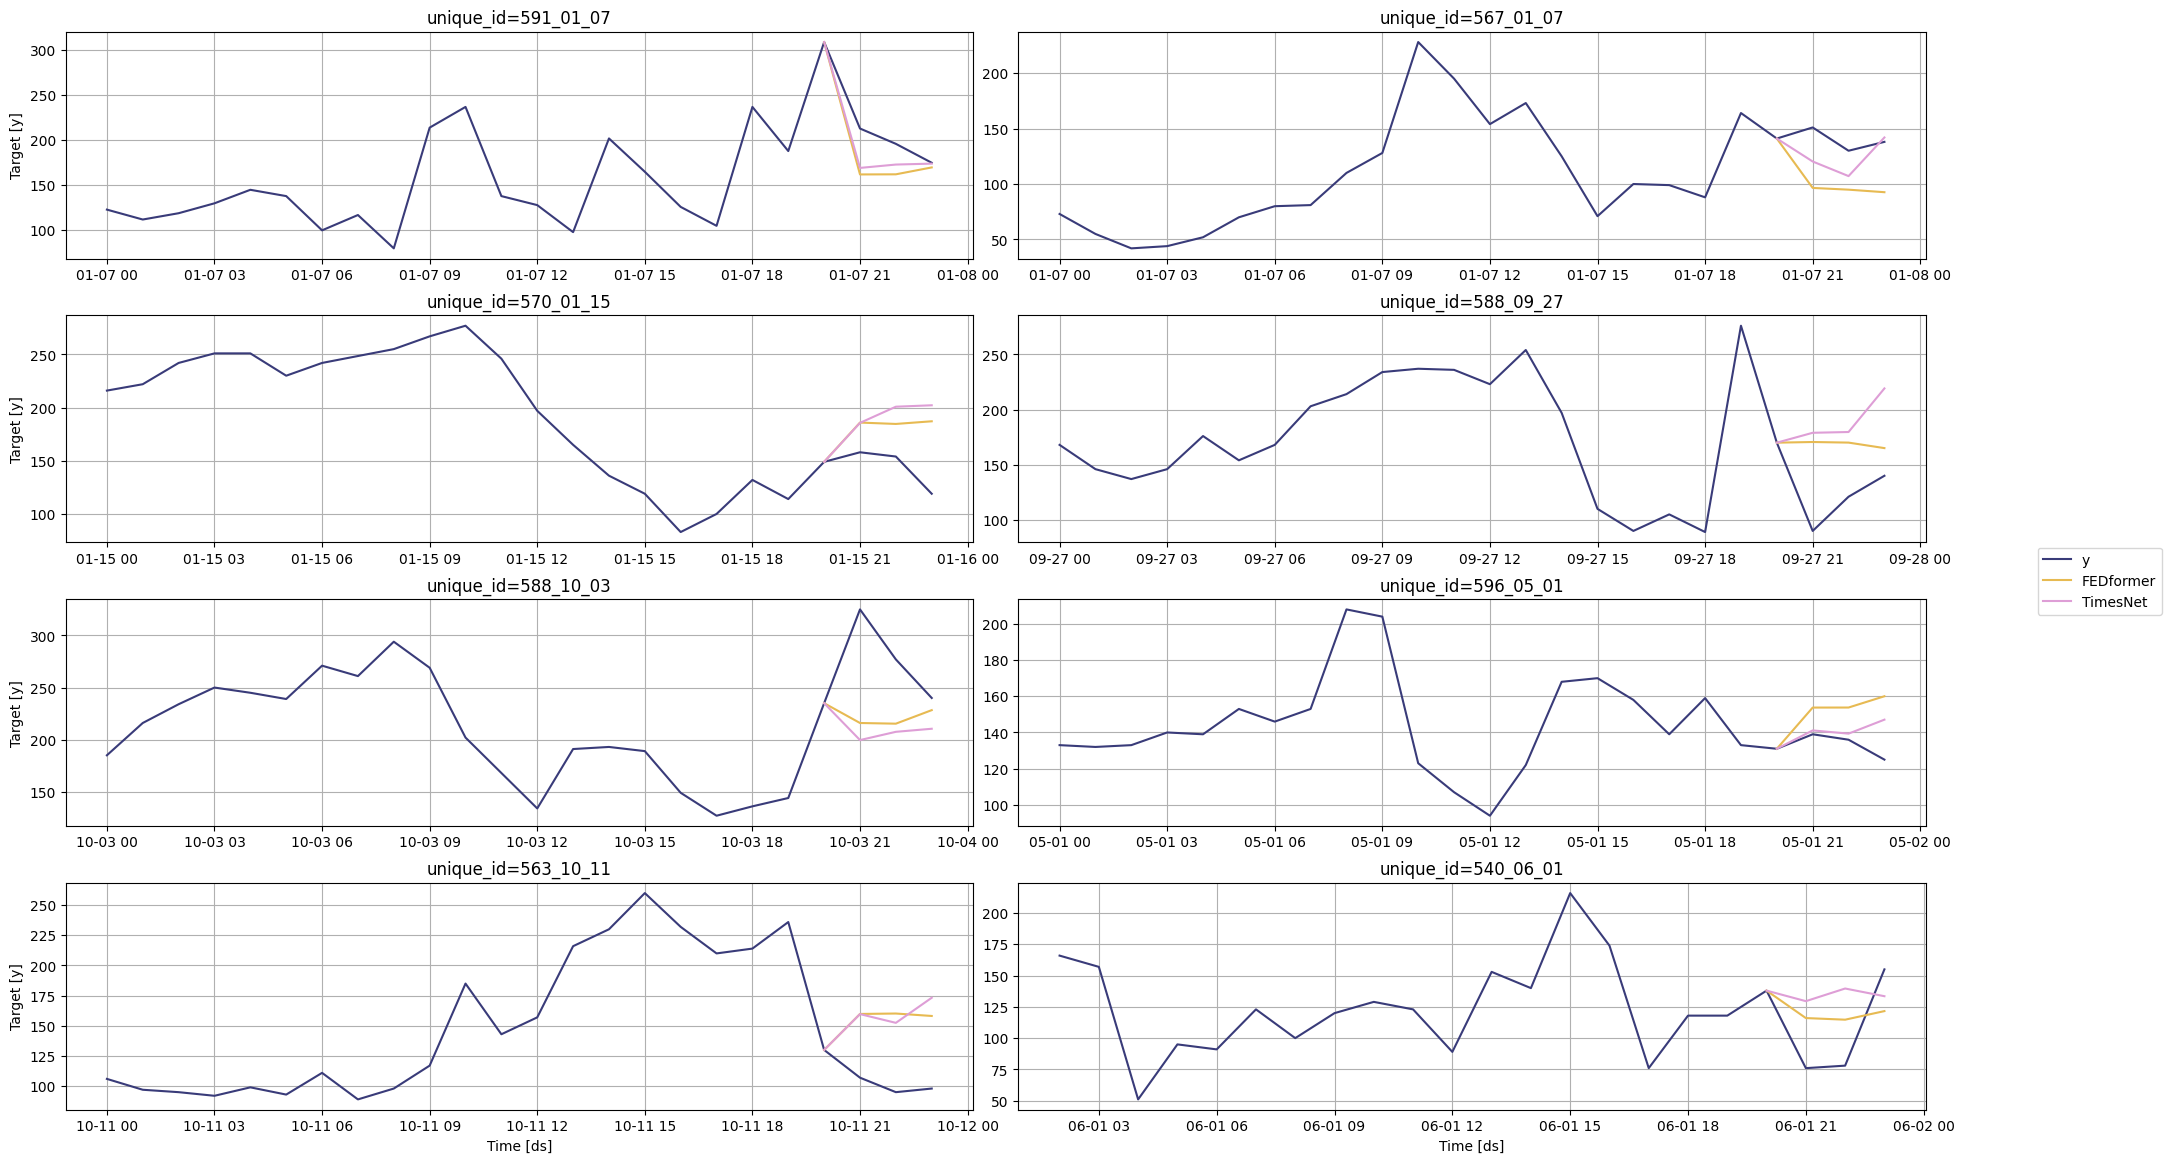

In [38]:
StatsForecast.plot(Y_df, df_to_plot_2.drop(columns=['y', 'cutoff']), max_insample_length=1260)

In [ ]:
from ray import tune

from statsforecast import StatsForecast
from neuralforecast import NeuralForecast
from neuralforecast.auto import AutoNHITS, AutoLSTM, AutoTimesNet
from neuralforecast.models import NHITS, TimesNet
from neuralforecast.losses.pytorch import MQLoss

In [ ]:
config_nhits = {
    "input_size": tune.choice([25, 35, 50]),              # Length of input window
    "start_padding_enabled": True,
    "n_blocks": 5*[1],                                              # Length of input window
    "mlp_units": 5 * [[64, 64]],                                  # Length of input window
    "n_pool_kernel_size": tune.choice([5*[1], 5*[2], 5*[4],         
                                      [8, 4, 2, 1, 1]]),            # MaxPooling Kernel size
    "n_freq_downsample": tune.choice([[8, 4, 2, 1, 1],
                                      [1, 1, 1, 1, 1]]),            # Interpolation expressivity ratios
    "learning_rate": tune.loguniform(1e-4, 1e-2),                   # Initial Learning rate
    "scaler_type": tune.choice([None]),                             # Scaler type
    "max_steps": tune.choice([5]),                               # Max number of training iterations
    "batch_size": tune.choice([1, 4, 10]),                          # Number of series in batch
    "windows_batch_size": tune.choice([128, 256, 512]),             # Number of windows in batch
    "random_seed": tune.randint(1, 20),                             # Random seed
}

config_lstm = {
    "input_size": tune.choice([48, 48*2, 48*3]),              # Length of input window
    "encoder_hidden_size": tune.choice([64, 128]),            # Hidden size of LSTM cells
    "encoder_n_layers": tune.choice([2,4]),                   # Number of layers in LSTM
    "learning_rate": tune.loguniform(1e-4, 1e-2),             # Initial Learning rate
    "scaler_type": tune.choice(['robust']),                   # Scaler type
    "max_steps": tune.choice([500, 1000]),                    # Max number of training iterations
    "batch_size": tune.choice([1, 4]),                        # Number of series in batch
    "random_seed": tune.randint(1, 20),                       # Random seed
}

config_TimesNet = {
    "input_size": tune.choice([48, 48*2, 48*3]),              # Length of input window
    "encoder_hidden_size": tune.choice([64, 128]),            # Hidden size of LSTM cells
    "encoder_n_layers": tune.choice([2,4]),                   # Number of layers in LSTM
    "learning_rate": tune.loguniform(1e-4, 1e-2),             # Initial Learning rate
    "scaler_type": tune.choice(['robust']),                   # Scaler type
    "max_steps": tune.choice([500, 1000]),                    # Max number of training iterations
    "batch_size": tune.choice([1, 4]),                        # Number of series in batch
    "random_seed": tune.randint(1, 20),                       # Random seed
}

nf = NeuralForecast(
    models=[
        NHITS(h=180, input_size=50, max_steps=5),
        AutoNHITS(h=180, config=config_nhits, loss=MQLoss(), num_samples=5),
        # AutoLSTM(h=3, config=config_lstm, loss=MQLoss(), num_samples=2),
        # AutoTimesNet(h=48, config=config_TimesNet, loss=MQLoss(), num_samples=5)
    ],
    freq='min'
)

In [ ]:
nf.fit(df=Y_df)

In [ ]:
fcst_df = nf.predict()
fcst_df.columns = fcst_df.columns.str.replace('-median', '')
fcst_df.head()

In [ ]:
StatsForecast.plot(Y_df, fcst_df, engine='matplotlib', max_insample_length=48, level=[80, 90])

In [ ]:
# Plot to unique_ids and some selected models
StatsForecast.plot(Y_df, fcst_df, models=["AutoLSTM"], unique_ids=["H107", "H104"], level=[80, 90], engine='matplotlib', )